<a href="https://colab.research.google.com/github/emiliomartineziteso/sim-mat/blob/main/Tarea_1_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea - Ajuste de curvas

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

---
### Problema 1

Los siguientes datos representan el costo en dólares de la electricidad según Western Electricity Coordinating Council desde el 2014 (y su pronóstico para el 2040)

Tomado de:
https://www.quandl.com/data/EIA/AEO_2016_REF_NO_CPP_PRCE_NA_COMM_NA_ELC_NA_WECCRKS_NCNTPKWH_A-Electricity-End-Use-Prices-Commercial-Western-Electricity-Coordinating-Council-Rockies-No-CPP-AEO2016

In [ ]:
# Datos extraidos de la página de quandl
data = np.array([10.051101,  9.259127,  9.444813,  9.557723,  9.977324, 10.298326,
       10.447217, 10.550506, 10.590784, 10.657418, 10.743085, 10.831965,
       10.988435, 11.153055, 11.313326, 11.557165, 11.860136, 12.122511,
       12.356448, 12.611391, 12.814569, 13.111372, 13.357134, 13.559012,
       13.85861 , 14.135924, 14.436149])

1. Ajuste estos datos a polinomios de grado 1 hasta 3 (los datos en $x$ corresponden a los años de 2014 a 2040, sin embargo son valores muy grandes para elevarlos a una potencia, use una representación para estos años, por ejemplo $2014 \rightarrow 0$ y $2040\rightarrow 27$).

2. Muestre las tres curvas ajustadas junto a los datos de los costos en un solo gráfico

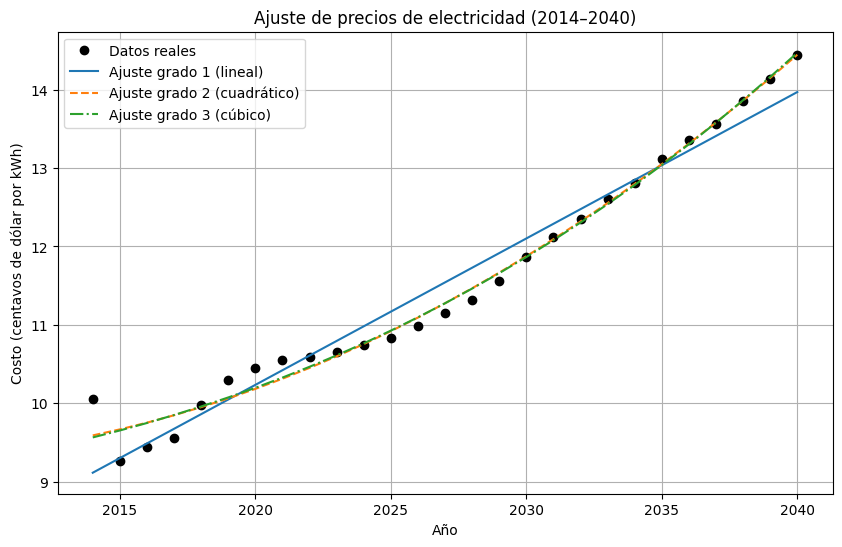

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Datos de costos (en centavos de dólar por kWh)
data = np.array([
    10.051101,  9.259127,  9.444813,  9.557723,  9.977324, 10.298326,
    10.447217, 10.550506, 10.590784, 10.657418, 10.743085, 10.831965,
    10.988435, 11.153055, 11.313326, 11.557165, 11.860136, 12.122511,
    12.356448, 12.611391, 12.814569, 13.111372, 13.357134, 13.559012,
    13.85861 , 14.135924, 14.436149
])

# Años desde 2014 hasta 2040
x = np.arange(0, len(data))  # Representa 2014→0, 2015→1, ..., 2040→26
years = np.arange(2014, 2014 + len(data))  # Para el eje real de años

# Ajustes polinomiales de grado 1, 2 y 3
p1 = np.polyfit(x, data, 1)
p2 = np.polyfit(x, data, 2)
p3 = np.polyfit(x, data, 3)

# Evaluar los polinomios en los puntos x
y1 = np.polyval(p1, x)
y2 = np.polyval(p2, x)
y3 = np.polyval(p3, x)

# --- Gráfica ---
plt.figure(figsize=(10, 6))
plt.plot(years, data, 'o', label='Datos reales', color='black')
plt.plot(years, y1, '-', label='Ajuste grado 1 (lineal)')
plt.plot(years, y2, '--', label='Ajuste grado 2 (cuadrático)')
plt.plot(years, y3, '-.', label='Ajuste grado 3 (cúbico)')

plt.title('Ajuste de precios de electricidad (2014–2040)')
plt.xlabel('Año')
plt.ylabel('Costo (centavos de dólar por kWh)')
plt.legend()
plt.grid(True)
plt.show()


---

___
### Problema 2

El archivo `population_data.csv` contiene información histórica anual de México relativa a la población, nacimientos y muertes desde el año 1950 hasta el año 2015. La primer columna corresponde a los años, la segunda a la población, la tercera a los nacimientos y la última a los decesos.

Tomado de: https://en.wikipedia.org/wiki/Demographics_of_Mexico.

Importe estos datos usando la función `read_csv` del paquete `pandas`

1. Usando los años como variable independiente $x$ y la población como variable dependiente $y$, ajustar polinomios de grado 1 hasta grado 3.

    * Mostrar en un solo gráfico los datos de población contra los años, y los polinomios ajustados.

    * Graficar el error cuadrático acumulado contra el número de términos.

2. Repetir el punto 1 usando los nacimientos como variable dependiente $y$. Grafique las curvas ajustadas junto con los datos de nacimientos. Vea en un gráfico el error acumulado.

In [ ]:
data = pd.read_csv('population_data.csv')

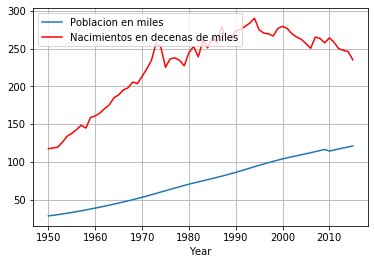

In [ ]:
# Se muestra la gráfica. Vea como los datos son escalados, esto le ayudará en el cálculo
# de la regresión.

plt.plot(data.values[:,0],data.values[:,1]/1000,label=data.columns[1]+' en miles')
plt.plot(data.values[:,0],data.values[:,2]/10000,'r',label=data.columns[2]+' en decenas de miles')
plt.legend(loc=2)
plt.xlabel(data.columns[0])
plt.grid()

In [4]:
from google.colab import files
uploaded = files.upload()


---

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === 1. Importar datos ===
data = pd.read_csv('population_data.csv')

# Variables
x = data.values[:, 0]       # Años
y_pob = data.values[:, 1]   # Población
y_nac = data.values[:, 2]   # Nacimientos

# Para evitar números muy grandes (años), reescalamos:
x_scaled = x - x[0]   # 1950 -> 0, 1951 -> 1, etc.

# === 2. Ajustes polinomiales de grado 1, 2 y 3 ===
grados = [1, 2, 3]
errores_pob = []
errores_nac = []

plt.figure(figsize=(10, 6))
plt.scatter(x, y_pob, color='black', label='Datos de población', s=20)

for g in grados:
    p = np.polyfit(x_scaled, y_pob, g)
    y_pred = np.polyval(p, x_scaled)
    plt.plot(x, y_pred, label=f'Polinomio grado {g}')

    # Error cuadrático acumulado
    error = np.sum((y_pob - y_pred)**2)
    errores_pob.append(error)

plt.title('Ajuste polinomial de la población en México (1950–2015)')
plt.xlabel('Año')
plt.ylabel('Población')
plt.legend()
plt.grid(True)
plt.show()

# === 3. Graficar error cuadrático acumulado (población) ===
plt.figure(figsize=(8, 5))
plt.plot(grados, errores_pob, 'o-', color='blue')
plt.title('Error cuadrático acumulado (Población)')
plt.xlabel('Grado del polinomio')
plt.ylabel('Error cuadrático')
plt.grid(True)
plt.show()

# === 4. Repetir el ajuste con nacimientos ===
plt.figure(figsize=(10, 6))
plt.scatter(x, y_nac, color='red', label='Datos de nacimientos', s=20)

for g in grados:
    p = np.polyfit(x_scaled, y_nac, g)
    y_pred = np.polyval(p, x_scaled)
    plt.plot(x, y_pred, label=f'Polinomio grado {g}')

    # Error cuadrático acumulado
    error = np.sum((y_nac - y_pred)**2)
    errores_nac.append(error)

plt.title('Ajuste polinomial de nacimientos en México (1950–2015)')
plt.xlabel('Año')
plt.ylabel('Nacimientos')
plt.legend()
plt.grid(True)
plt.show()

# === 5. Graficar error cuadrático acumulado (nacimientos) ===
plt.figure(figsize=(8, 5))
plt.plot(grados, errores_nac, 'o-', color='red')
plt.title('Error cuadrático acumulado (Nacimientos)')
plt.xlabel('Grado del polinomio')
plt.ylabel('Error cuadrático')
plt.grid(True)
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'population_data.csv'